# Personal Information
Name: **Alexandra Holíková**

StudentID: **14236788**

Email: [**alexandra.holikova@student.uva.nl**](alexandra.holikova@student.uva.nl)

Github link: https://github.com/alexandraholik/MSc_Thesis.git

# 05 — Korean Evaluation Set

Applies detection approaches to the Korean test set from Song et al. (2023).

**Dataset:** 1,600 annotated articles (814 contextomized, 786 modified).  
**Primary metric:** AUC. F1 at fixed τ=0.5 reported for reference.

**Approaches evaluated:**
1. Cosine similarity baseline
2. mDeBERTa NLI
3. GPT-4o Direct — context window (English prompt)
4. GPT-4o CoT — context window (English prompt)
5. GPT-4o Direct — full article (English prompt)  ← new
6. GPT-4o CoT — full article (English prompt)  ← new
7. GPT-4o CoT — context window, Korean prompt  ← new
8. GPT-4o CoT — context window, XL-CoT (reason in English)  ← new

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
load_dotenv()

THRESHOLD = 0.5

In [45]:
from sklearn.metrics import confusion_matrix

def evaluate(y_true, scores, threshold=THRESHOLD, name=''):
    """Compute AUC, F1, sensitivity, specificity, precision."""
    preds = (scores >= threshold).astype(int)
    auc   = roc_auc_score(y_true, scores)
    f1    = f1_score(y_true, preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{'=== ' + name + ' ===' if name else ''}")
    print(f"AUC: {auc:.3f}  |  F1: {f1:.3f}  |  Sens: {sensitivity:.3f}  |  Spec: {specificity:.3f}  |  Prec: {precision:.3f}")
    return preds, auc, f1, sensitivity, specificity, precision

In [3]:
old = pd.read_csv('data/korean_predictions.csv')
print(old.columns.tolist())
print(old.shape)

['headline_quote', 'body_quotes', 'headline', 'url', 'label', 'best_body_sentence', 'prev_sentence', 'next_sentence', 'best_sim', 'body', 'score_cosine', 'pred_cosine', 'score_nli', 'pred_nli', 'score_gpt', 'pred_gpt', 'score_cot', 'pred_cot', 'score_gpt_full', 'pred_gpt_full', 'score_cot_full', 'pred_cot_full', 'score_cot_ko', 'pred_cot_ko', 'score_cot_xlcot', 'pred_cot_xlcot', 'score_cot_fs', 'pred_cot_fs']
(1600, 28)


---
## 1. Quote Matching

The Korean set provides `body_quotes` (extracted quoted spans) and the full `body` text, but no pre-matched sentence. We replicate the matching procedure from Notebook 02: the headline quote is matched against all body sentences using `paraphrase-multilingual-mpnet-base-v2`, and the best-matching sentence plus its neighbours form the context window.

In [46]:
import re

df = pd.read_csv('data_new/korean_matched.csv')
df['label'] = df['label'].astype(int)
for col in ['prev_sentence', 'next_sentence', 'best_body_sentence']:
    df[col] = df[col].fillna('')

# Join full article body from original dataset for full-article GPT variants
ko_full = pd.read_pickle('data/contextomized_quote.pkl')
df = df.merge(ko_full[['url', 'body']], on='url', how='left')
print(f"Body joined: {df['body'].notna().sum()} / {len(df)}")

y_true = df['label'].values
print(f"Loaded: {len(df)} articles")
print(f"Contextomized: {y_true.sum()}  |  Modified: {(y_true==0).sum()}")
print(f"Mean similarity: {df['best_sim'].mean():.3f}")

def clean_body(html):
    """Strip HTML tags and collapse whitespace from raw article body."""
    text = re.sub(r'<[^>]+>', ' ', str(html))
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:6000]


Body joined: 1600 / 1600
Loaded: 1600 articles
Contextomized: 814  |  Modified: 786
Mean similarity: 0.558


In [47]:
def build_premise(row):
    """Concatenate context window: prev + best body sentence + next."""
    parts = [row['prev_sentence'], row['best_body_sentence'], row['next_sentence']]
    return ' '.join(p for p in parts if p).strip()

---
## 2. Approach 1 — Cosine Similarity Threshold (τ=0.5)

In [48]:
cosine_scores = 1 - df['best_sim'].values
cosine_preds, cosine_auc, cosine_f1, cosine_sens, cosine_spec, cosine_prec = evaluate(
    y_true, cosine_scores, name='Cosine'
)

=== Cosine ===
AUC: 0.596  |  F1: 0.492  |  Sens: 0.419  |  Spec: 0.707  |  Prec: 0.597


---
## 3. Approach 2 — NLI (mDeBERTa)

Run on Snellius if slow on CPU — save scores to `data/korean_nli_scores.csv` using the same pattern as Notebook 04.

In [49]:
nli_results = pd.read_csv('data/korean_nli_scores.csv')
nli_scores  = nli_results['score_nli'].values
nli_preds   = nli_results['pred_nli'].values
_, nli_auc, nli_f1, nli_sens, nli_spec, nli_prec = evaluate(y_true, nli_scores, name='NLI')

=== NLI ===
AUC: 0.560  |  F1: 0.249  |  Sens: 0.157  |  Spec: 0.892  |  Prec: 0.601


---
## 4. Approaches 3–10 — GPT-4o

Eight GPT-4o variants across three dimensions:
- **Prompt strategy:** direct vs. chain-of-thought
- **Input scope:** context window (3 sentences) vs. full article body
- **Prompt language:** English vs. Korean vs. cross-lingual CoT (XL-CoT)

The Korean prompt and XL-CoT variants are applied only under the context window condition, following the English results which showed full-article input rarely helps. All calls use `gpt-4o` with `temperature=0`.

In [50]:
import openai
import json
import os
import time
import re

client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

# English prompt
SYSTEM_DIRECT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's intended meaning. Minor editorial changes are acceptable: grammatical adaptation, brevity, pronoun replacement, or paraphrase that does not alter what the speaker actually claimed.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing qualifications, stripping hedges, omitting key context, or combining fragments in a way that produces a materially different claim than the speaker made.

The bar for CONTEXTOMIZED is semantic distortion, not surface difference. When in doubt, prefer MODIFIED.

You will receive a headline quote and the body text where it originated.
Output ONLY valid JSON with exactly two fields:
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""


SYSTEM_COT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

Reason step by step, then output ONLY valid JSON with exactly four fields:
- "step1": What is the speaker's intended meaning in the body context? (1 sentence)
- "step2": Does the headline quote preserve or distort that meaning? (1 sentence)
- "label": "CONTEXTOMIZED" or "MODIFIED"
- "probability": float 0.0-1.0, your estimated probability that the quote is contextomized"""

# ── Korean prompt ────────────────────────────────────────────────────────────
# Motivation: test whether matching prompt language to input language improves
# comprehension on Korean text. Prior work (Shi et al., 2022; Ko et al., 2025)
# suggests Korean performance gaps stem partly from input comprehension difficulty.
# Expected result: no improvement or slight degradation, consistent with the finding
# that English prompts outperform task-language prompts for most LLMs (Shi et al., 2022).
SYSTEM_COT_KO = """당신은 인용구 정확성을 전문으로 하는 저널리즘 윤리 전문가입니다.

정의:
- MODIFIED: 헤드라인 인용구가 발언자의 의미를 충실하게 보존한 경우.
- CONTEXTOMIZED: 헤드라인 인용구가 문맥 제거, 강조점 변경, 또는 오해를 유발하는 방식으로 발언자의 본래 의도를 왜곡한 경우.

단계적으로 추론한 후, 정확히 네 개의 필드를 포함하는 유효한 JSON만 출력하세요:
- \"step1\": 본문 맥락에서 발언자의 의도는 무엇인가? (1문장)
- \"step2\": 헤드라인 인용구가 그 의미를 보존하는가, 아니면 왜곡하는가? (1문장)
- \"label\": \"CONTEXTOMIZED\" 또는 \"MODIFIED\"
- \"probability\": 0.0~1.0 사이의 소수, 인용구가 문맥 왜곡일 확률"""

# ── Cross-lingual CoT prompt (XL-CoT) ────────────────────────────────────────
# Motivation: force intermediate reasoning into English regardless of input language.
# Qin et al. (2023, EMNLP) show this improves zero-shot reasoning transferability
# over native-language CoT. Shi et al. (2022) find English reasoning chains
# outperform native-language chains across all tested languages.
SYSTEM_COT_XLCOT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

The input text may be in any language. Always reason and write your intermediate steps in English, regardless of the input language. This helps you reason precisely about semantic distinctions.

Reason step by step in English, then output ONLY valid JSON with exactly four fields:
- \"step1\": What is the speaker's intended meaning in the body context? (1 sentence, in English)
- \"step2\": Does the headline quote preserve or distort that meaning? (1 sentence, in English)
- \"label\": \"CONTEXTOMIZED\" or \"MODIFIED\"
- \"probability\": float 0.0-1.0, your estimated probability that the quote is contextomized"""

# ── Shared parser and runner ─────────────────────────────────────────────────
def parse_response(text):
    text = text.strip().replace('```json','').replace('```','')
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        label_match = re.search(r'"label"\s*:\s*"(CONTEXTOMIZED|MODIFIED)"', text)
        prob_match  = re.search(r'"probability"\s*:\s*([0-9.]+)', text)
        if label_match and prob_match:
            return label_match.group(1), float(prob_match.group(1))
        raise
    return parsed['label'], float(parsed['probability'])

def run_gpt(df, system_prompt, input_type='context', max_tokens=60, desc=''):
    """Run GPT classification over the full dataframe.

    Parameters
    ----------
    input_type : 'context' — 3-sentence window; 'full' — full article body (≤6000 chars)
    desc       : short label printed in progress updates
    """
    labels, scores = [], []
    for i, (_, row) in enumerate(df.iterrows()):
        try:
            if input_type == 'context':
                body_text = build_premise(row)
                field = 'BODY CONTEXT'
            else:
                body_text = clean_body(row['body'])
                field = 'FULL ARTICLE'
            user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\n{field}: "{body_text}"'
            response = client.chat.completions.create(
                model='gpt-4o',
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user',   'content': user_msg}
                ],
                temperature=0,
                max_tokens=max_tokens
            )
            label, prob = parse_response(response.choices[0].message.content)
            labels.append(1 if label == 'CONTEXTOMIZED' else 0)
            scores.append(prob)
        except Exception as e:
            print(f'Row {i} failed: {e}')
            labels.append(0)
            scores.append(0.5)
        if (i + 1) % 100 == 0:
            print(f'  [{desc}] {i+1}/{len(df)} done')
        time.sleep(0.3)
    return np.array(labels), np.array(scores)

In [51]:
# Pilot on 5 rows before full runs — tests all four prompt variants
PILOT_CONFIGS = [
    ('Direct EN (ctx)',   SYSTEM_DIRECT,    'context', 60),
    ('CoT EN (ctx)',      SYSTEM_COT,       'context', 200),
    ('CoT KO (ctx)',      SYSTEM_COT_KO,    'context', 200),
    ('CoT XL-CoT (ctx)', SYSTEM_COT_XLCOT, 'context', 200),
]

for label, sys_prompt, itype, maxtok in PILOT_CONFIGS:
    print(f'\n--- Pilot: {label} ---')
    for _, row in df.head(5).iterrows():
        body_text = build_premise(row)
        user_msg  = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY CONTEXT: "{body_text}"'
        response  = client.chat.completions.create(
            model='gpt-4o',
            messages=[
                {'role': 'system', 'content': sys_prompt},
                {'role': 'user',   'content': user_msg}
            ],
            temperature=0, max_tokens=maxtok
        )
        pred_label, prob = parse_response(response.choices[0].message.content)
        gt = row['label']
        print(f'  gt={gt}  pred={pred_label}  prob={prob:.2f}  |  {str(row["headline_quote"])[:60]}')
        time.sleep(0.3)


--- Pilot: Direct EN (ctx) ---
  gt=1  pred=MODIFIED  prob=0.20  |  ['한화그룹 비선조직이 비자금 조성 주도']
  gt=1  pred=MODIFIED  prob=0.10  |  ['한국, 올해 국민소득 2만불 재돌파']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['새해 경기회복 빨라진다']
  gt=0  pred=MODIFIED  prob=0.10  |  ['반짝 늘던 매수문의 다시 잠잠']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['올해 몸 조심해야 할 세력은...']

--- Pilot: CoT EN (ctx) ---
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['한화그룹 비선조직이 비자금 조성 주도']
  gt=1  pred=CONTEXTOMIZED  prob=0.85  |  ['한국, 올해 국민소득 2만불 재돌파']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['새해 경기회복 빨라진다']
  gt=0  pred=MODIFIED  prob=0.10  |  ['반짝 늘던 매수문의 다시 잠잠']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['올해 몸 조심해야 할 세력은...']

--- Pilot: CoT KO (ctx) ---
  gt=1  pred=MODIFIED  prob=0.10  |  ['한화그룹 비선조직이 비자금 조성 주도']
  gt=1  pred=CONTEXTOMIZED  prob=0.85  |  ['한국, 올해 국민소득 2만불 재돌파']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['새해 경기회복 빨라진다']
  gt=0  pred=MODIFIED  prob=0.10  |  ['반짝 늘던 매수문의 다시 잠잠']
  gt=1  pred=CONTEXTOMIZED  prob=0.85  |  ['올

In [52]:
# GPT-4o Direct, context window — English prompt (~1600 calls, ~10 min)
gpt_labels, gpt_scores = run_gpt(df, SYSTEM_DIRECT, input_type='context', max_tokens=60, desc='Direct EN ctx')
gpt_preds, gpt_auc, gpt_f1, gpt_sens, gpt_spec, gpt_prec = evaluate(y_true, gpt_scores, name='GPT-4o Direct (ctx, EN)')
pd.DataFrame({'score': gpt_scores, 'pred': gpt_labels, 'label': y_true}).to_csv('data/korean_gpt_direct_ctx.csv', index=False)

  [Direct EN ctx] 100/1600 done
  [Direct EN ctx] 200/1600 done
  [Direct EN ctx] 300/1600 done
  [Direct EN ctx] 400/1600 done
  [Direct EN ctx] 500/1600 done
  [Direct EN ctx] 600/1600 done
  [Direct EN ctx] 700/1600 done
  [Direct EN ctx] 800/1600 done
  [Direct EN ctx] 900/1600 done
  [Direct EN ctx] 1000/1600 done
  [Direct EN ctx] 1100/1600 done
  [Direct EN ctx] 1200/1600 done
  [Direct EN ctx] 1300/1600 done
  [Direct EN ctx] 1400/1600 done
  [Direct EN ctx] 1500/1600 done
  [Direct EN ctx] 1600/1600 done
=== GPT-4o Direct (ctx, EN) ===
AUC: 0.588  |  F1: 0.630  |  Sens: 0.710  |  Spec: 0.436  |  Prec: 0.566


In [36]:
# GPT-4o CoT, context window — English prompt (~1600 calls, ~15 min)
cot_labels, cot_scores = run_gpt(df, SYSTEM_COT, input_type='context', max_tokens=200, desc='CoT EN ctx')
cot_preds, cot_auc, cot_f1, cot_sens, cot_spec, cot_prec = evaluate(y_true, cot_scores, name='GPT-4o CoT (ctx, EN)')
pd.DataFrame({'score': cot_scores, 'pred': cot_labels, 'label': y_true}).to_csv('data/korean_gpt_cot_ctx.csv', index=False)

Row 33 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN ctx] 100/1600 done
  [CoT EN ctx] 200/1600 done
  [CoT EN ctx] 300/1600 done
Row 379 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN ctx] 400/1600 done
  [CoT EN ctx] 500/1600 done
Row 566 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN ctx] 600/1600 done
  [CoT EN ctx] 700/1600 done
  [CoT EN ctx] 800/1600 done
  [CoT EN ctx] 900/1600 done
  [CoT EN ctx] 1000/1600 done
Row 1031 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN ctx] 1100/1600 done
  [CoT EN ctx] 1200/1600 done
  [CoT EN ctx] 1300/1600 done
  [CoT EN ctx] 1400/1600 done
Row 1442 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN ctx] 1500/1600 done
Row 1567 failed: Expecting value: line 1 column 1 (char 0)
Row 1581 failed: Expecting value: line 1 column 1 (char 0)
Row 1599 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN ctx] 1600/1600 done
=== GPT-4o CoT (ctx, EN) ===
AUC: 0.548  |  F1: 0.542  |  Sen

In [53]:
# GPT-4o Direct, full article — English prompt (~1600 calls, ~15 min)
# Full article body truncated to 6000 chars. Omitted from original Table 3;
# now included to complete the evaluation matrix and test whether the English
# full-article degradation pattern replicates on Korean input.
gpt_full_labels, gpt_full_scores = run_gpt(df, SYSTEM_DIRECT, input_type='full', max_tokens=60, desc='Direct EN full')
gpt_full_preds, gpt_full_auc, gpt_full_f1, gpt_full_sens, gpt_full_spec, gpt_full_prec = evaluate(y_true, gpt_full_scores, name='GPT-4o Direct (full, EN)')
pd.DataFrame({'score': gpt_full_scores, 'pred': gpt_full_labels, 'label': y_true}).to_csv('data/korean_gpt_direct_full.csv', index=False)

  [Direct EN full] 100/1600 done
  [Direct EN full] 200/1600 done
  [Direct EN full] 300/1600 done
  [Direct EN full] 400/1600 done
  [Direct EN full] 500/1600 done
  [Direct EN full] 600/1600 done
  [Direct EN full] 700/1600 done
  [Direct EN full] 800/1600 done
  [Direct EN full] 900/1600 done
  [Direct EN full] 1000/1600 done
  [Direct EN full] 1100/1600 done
  [Direct EN full] 1200/1600 done
  [Direct EN full] 1300/1600 done
  [Direct EN full] 1400/1600 done
  [Direct EN full] 1500/1600 done
  [Direct EN full] 1600/1600 done
=== GPT-4o Direct (full, EN) ===
AUC: 0.585  |  F1: 0.500  |  Sens: 0.419  |  Spec: 0.734  |  Prec: 0.620


In [38]:
# GPT-4o CoT, full article — English prompt (~1600 calls, ~20 min)
cot_full_labels, cot_full_scores = run_gpt(df, SYSTEM_COT, input_type='full', max_tokens=200, desc='CoT EN full')
cot_full_preds, cot_full_auc, cot_full_f1, cot_full_sens, cot_full_spec, cot_full_prec = evaluate(y_true, cot_full_scores, name='GPT-4o CoT (full, EN)')
pd.DataFrame({'score': cot_full_scores, 'pred': cot_full_labels, 'label': y_true}).to_csv('data/korean_gpt_cot_full.csv', index=False)

  [CoT EN full] 100/1600 done
  [CoT EN full] 200/1600 done
  [CoT EN full] 300/1600 done
  [CoT EN full] 400/1600 done
  [CoT EN full] 500/1600 done
  [CoT EN full] 600/1600 done
  [CoT EN full] 700/1600 done
  [CoT EN full] 800/1600 done
  [CoT EN full] 900/1600 done
  [CoT EN full] 1000/1600 done
  [CoT EN full] 1100/1600 done
  [CoT EN full] 1200/1600 done
  [CoT EN full] 1300/1600 done
  [CoT EN full] 1400/1600 done
  [CoT EN full] 1500/1600 done
  [CoT EN full] 1600/1600 done
=== GPT-4o CoT (full, EN) ===
AUC: 0.542  |  F1: 0.475  |  Sens: 0.418  |  Spec: 0.646  |  Prec: 0.550


### Prompt language variants — context window only

Two additional prompt configurations test whether rewriting the instructions in Korean, or explicitly forcing English-language intermediate reasoning (cross-lingual CoT, XL-CoT), improves performance on Korean input.

**Korean prompt:** Tests whether matching prompt language to input language reduces comprehension difficulty (Ko et al., 2025). Prior evidence across tasks suggests English prompts tend to outperform task-language prompts for English-dominant LLMs (Shi et al., 2022), so this is a directional hypothesis.

**XL-CoT prompt:** Instructs the model to produce intermediate reasoning explicitly in English regardless of input language (Qin et al., EMNLP 2023). The reasoning chain is in English; only the input text is Korean.

In [39]:
# GPT-4o CoT, context window — Korean prompt (~1600 calls, ~15 min)
cot_ko_labels, cot_ko_scores = run_gpt(df, SYSTEM_COT_KO, input_type='context', max_tokens=200, desc='CoT KO ctx')
cot_ko_preds, cot_ko_auc, cot_ko_f1, cot_ko_sens, cot_ko_spec, cot_ko_prec = evaluate(y_true, cot_ko_scores, name='GPT-4o CoT (ctx, KO prompt)')
pd.DataFrame({'score': cot_ko_scores, 'pred': cot_ko_labels, 'label': y_true}).to_csv('data/korean_gpt_cot_ctx_ko.csv', index=False)

  [CoT KO ctx] 100/1600 done
  [CoT KO ctx] 200/1600 done
  [CoT KO ctx] 300/1600 done
Row 396 failed: Expecting value: line 1 column 1 (char 0)
  [CoT KO ctx] 400/1600 done
  [CoT KO ctx] 500/1600 done
  [CoT KO ctx] 600/1600 done
  [CoT KO ctx] 700/1600 done
  [CoT KO ctx] 800/1600 done
  [CoT KO ctx] 900/1600 done
  [CoT KO ctx] 1000/1600 done
Row 1048 failed: Expecting value: line 1 column 1 (char 0)
  [CoT KO ctx] 1100/1600 done
  [CoT KO ctx] 1200/1600 done
  [CoT KO ctx] 1300/1600 done
  [CoT KO ctx] 1400/1600 done
  [CoT KO ctx] 1500/1600 done
  [CoT KO ctx] 1600/1600 done
=== GPT-4o CoT (ctx, KO prompt) ===
AUC: 0.537  |  F1: 0.586  |  Sens: 0.657  |  Spec: 0.394  |  Prec: 0.529


In [40]:
# GPT-4o CoT, context window — XL-CoT prompt (reason in English) (~1600 calls, ~15 min)
cot_xlcot_labels, cot_xlcot_scores = run_gpt(df, SYSTEM_COT_XLCOT, input_type='context', max_tokens=200, desc='XL-CoT ctx')
cot_xlcot_preds, cot_xlcot_auc, cot_xlcot_f1, cot_xlcot_sens, cot_xlcot_spec, cot_xlcot_prec = evaluate(y_true, cot_xlcot_scores, name='GPT-4o CoT (ctx, XL-CoT)')
pd.DataFrame({'score': cot_xlcot_scores, 'pred': cot_xlcot_labels, 'label': y_true}).to_csv('data/korean_gpt_cot_ctx_xlcot.csv', index=False)

Row 33 failed: Expecting value: line 1 column 1 (char 0)
  [XL-CoT ctx] 100/1600 done
  [XL-CoT ctx] 200/1600 done
  [XL-CoT ctx] 300/1600 done
Row 379 failed: Expecting value: line 1 column 1 (char 0)
Row 396 failed: Expecting value: line 1 column 1 (char 0)
  [XL-CoT ctx] 400/1600 done
  [XL-CoT ctx] 500/1600 done
Row 519 failed: Expecting value: line 1 column 1 (char 0)
Row 542 failed: Expecting value: line 1 column 1 (char 0)
Row 566 failed: Expecting value: line 1 column 1 (char 0)
  [XL-CoT ctx] 600/1600 done
  [XL-CoT ctx] 700/1600 done
Row 734 failed: Expecting value: line 1 column 1 (char 0)
  [XL-CoT ctx] 800/1600 done
  [XL-CoT ctx] 900/1600 done
Row 916 failed: Expecting value: line 1 column 1 (char 0)
Row 922 failed: Expecting value: line 1 column 1 (char 0)
  [XL-CoT ctx] 1000/1600 done
Row 1022 failed: Expecting value: line 1 column 1 (char 0)
Row 1031 failed: Expecting value: line 1 column 1 (char 0)
Row 1048 failed: Expecting value: line 1 column 1 (char 0)
  [XL-CoT c

---
## 5. Results Summary

Comparison against Song et al. (2023) reported results on this identical test set.

In [54]:
results = pd.DataFrame([
    # ── Song et al. supervised baselines (Korean test set) ───────────────────
    {'Method': 'BERT',              'AUC': 0.662, 'F1': 0.665, 'Sens.': '--', 'Spec.': '--', 'Prec.': '--', 'Setting': 'supervised', 'Input': '--',     'Prompt': '--'},
    {'Method': 'BERT fine-tune',    'AUC': 0.749, 'F1': 0.754, 'Sens.': '--', 'Spec.': '--', 'Prec.': '--', 'Setting': 'supervised', 'Input': '--',     'Prompt': '--'},
    {'Method': 'QuoteCSE',          'AUC': 0.768, 'F1': 0.770, 'Sens.': '--', 'Spec.': '--', 'Prec.': '--', 'Setting': 'supervised', 'Input': '--',     'Prompt': '--'},
    # ── Our approaches ───────────────────────────────────────────────────────
    {'Method': 'Cosine τ=0.5',      'AUC': round(cosine_auc,3),     'F1': round(cosine_f1,3),     'Sens.': round(cosine_sens,3),     'Spec.': round(cosine_spec,3),     'Prec.': round(cosine_prec,3),     'Setting': 'zero-shot', 'Input': '--',     'Prompt': '--'},
    {'Method': 'mDeBERTa NLI',      'AUC': round(nli_auc,3),        'F1': round(nli_f1,3),        'Sens.': round(nli_sens,3),        'Spec.': round(nli_spec,3),        'Prec.': round(nli_prec,3),        'Setting': 'zero-shot', 'Input': 'ctx',    'Prompt': '--'},
    {'Method': 'GPT-4o Direct',     'AUC': round(gpt_auc,3),        'F1': round(gpt_f1,3),        'Sens.': round(gpt_sens,3),        'Spec.': round(gpt_spec,3),        'Prec.': round(gpt_prec,3),        'Setting': 'zero-shot', 'Input': 'ctx',    'Prompt': 'EN direct'},
    {'Method': 'GPT-4o CoT',        'AUC': round(cot_auc,3),        'F1': round(cot_f1,3),        'Sens.': round(cot_sens,3),        'Spec.': round(cot_spec,3),        'Prec.': round(cot_prec,3),        'Setting': 'zero-shot', 'Input': 'ctx',    'Prompt': 'EN CoT'},
    {'Method': 'GPT-4o Direct',     'AUC': round(gpt_full_auc,3),   'F1': round(gpt_full_f1,3),   'Sens.': round(gpt_full_sens,3),   'Spec.': round(gpt_full_spec,3),   'Prec.': round(gpt_full_prec,3),   'Setting': 'zero-shot', 'Input': 'full',   'Prompt': 'EN direct'},
    {'Method': 'GPT-4o CoT',        'AUC': round(cot_full_auc,3),   'F1': round(cot_full_f1,3),   'Sens.': round(cot_full_sens,3),   'Spec.': round(cot_full_spec,3),   'Prec.': round(cot_full_prec,3),   'Setting': 'zero-shot', 'Input': 'full',   'Prompt': 'EN CoT'},
    {'Method': 'GPT-4o CoT',        'AUC': round(cot_ko_auc,3),     'F1': round(cot_ko_f1,3),     'Sens.': round(cot_ko_sens,3),     'Spec.': round(cot_ko_spec,3),     'Prec.': round(cot_ko_prec,3),     'Setting': 'zero-shot', 'Input': 'ctx',    'Prompt': 'KO CoT'},
    {'Method': 'GPT-4o CoT',        'AUC': round(cot_xlcot_auc,3),  'F1': round(cot_xlcot_f1,3),  'Sens.': round(cot_xlcot_sens,3),  'Spec.': round(cot_xlcot_spec,3),  'Prec.': round(cot_xlcot_prec,3),  'Setting': 'zero-shot', 'Input': 'ctx',    'Prompt': 'XL-CoT'},
])

print(results[['Method','Input','Prompt','Setting','AUC','F1','Sens.','Spec.','Prec.']].to_string(index=False))

        Method Input    Prompt    Setting   AUC    F1  Sens.  Spec.  Prec.
          BERT    --        -- supervised 0.662 0.665     --     --     --
BERT fine-tune    --        -- supervised 0.749 0.754     --     --     --
      QuoteCSE    --        -- supervised 0.768 0.770     --     --     --
  Cosine τ=0.5    --        --  zero-shot 0.596 0.492  0.419  0.707  0.597
  mDeBERTa NLI   ctx        --  zero-shot 0.560 0.249  0.157  0.892  0.601
 GPT-4o Direct   ctx EN direct  zero-shot 0.588 0.630   0.71  0.436  0.566
    GPT-4o CoT   ctx    EN CoT  zero-shot 0.548 0.542  0.533   0.55  0.551
 GPT-4o Direct  full EN direct  zero-shot 0.585 0.500  0.419  0.734   0.62
    GPT-4o CoT  full    EN CoT  zero-shot 0.542 0.475  0.418  0.646   0.55
    GPT-4o CoT   ctx    KO CoT  zero-shot 0.537 0.586  0.657  0.394  0.529
    GPT-4o CoT   ctx    XL-CoT  zero-shot 0.547 0.524  0.504  0.566  0.546


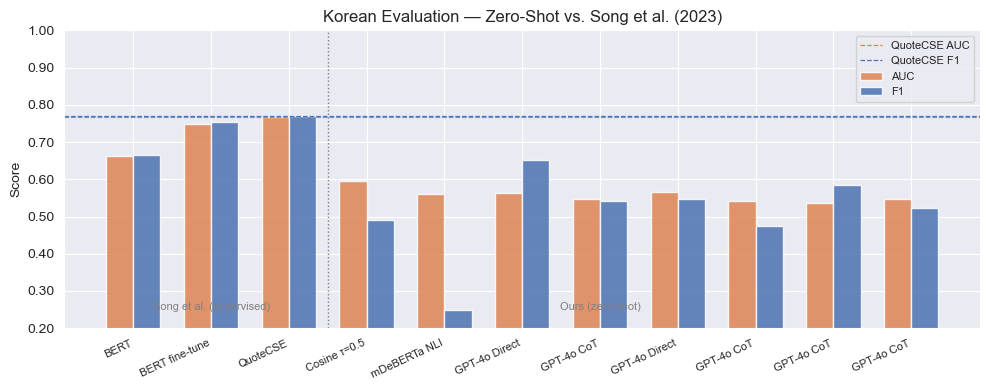

In [42]:
fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(len(results)), 0.35

ax.bar(x - w/2, pd.to_numeric(results['AUC'], errors='coerce'), w, label='AUC', color='#DD8452', alpha=0.85)
ax.bar(x + w/2, pd.to_numeric(results['F1'],  errors='coerce'), w, label='F1',  color='#4C72B0', alpha=0.85)

ax.axhline(0.768, color='#DD8452', linestyle='--', linewidth=0.9, label='QuoteCSE AUC')
ax.axhline(0.770, color='#4C72B0', linestyle='--', linewidth=0.9, label='QuoteCSE F1')
ax.axvline(2.5,   color='grey',    linestyle=':',  linewidth=1)
ax.text(1.0, 0.25, 'Song et al. (supervised)', ha='center', fontsize=8, color='grey')
ax.text(6.0, 0.25, 'Ours (zero-shot)',          ha='center', fontsize=8, color='grey')

ax.set_xticks(x)
ax.set_xticklabels(results['Method'], rotation=25, ha='right', fontsize=8)
ax.set_ylim(0.2, 1.0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_ylabel('Score')
ax.set_title('Korean Evaluation — Zero-Shot vs. Song et al. (2023)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('data/korean_results_comparison.png', dpi=150)
plt.show()

---
## 6. Save All Predictions

In [43]:
df['score_cosine']      = cosine_scores
df['pred_cosine']       = cosine_preds
df['score_nli']         = nli_scores
df['pred_nli']          = nli_preds
df['score_gpt']         = gpt_scores
df['pred_gpt']          = gpt_preds
df['score_cot']         = cot_scores
df['pred_cot']          = cot_preds
df['score_gpt_full']    = gpt_full_scores
df['pred_gpt_full']     = gpt_full_preds
df['score_cot_full']    = cot_full_scores
df['pred_cot_full']     = cot_full_preds
df['score_cot_ko']      = cot_ko_scores
df['pred_cot_ko']       = cot_ko_preds
df['score_cot_xlcot']   = cot_xlcot_scores
df['pred_cot_xlcot']    = cot_xlcot_preds

df.to_csv('data/korean_predictions.csv', index=False)
print('Saved: data/korean_predictions.csv')
print()
print(results[['Method','Input','Prompt','Setting','AUC','F1']].to_string(index=False))

Saved: data/korean_predictions.csv

        Method Input    Prompt    Setting   AUC    F1
          BERT    --        -- supervised 0.662 0.665
BERT fine-tune    --        -- supervised 0.749 0.754
      QuoteCSE    --        -- supervised 0.768 0.770
  Cosine τ=0.5    --        --  zero-shot 0.596 0.492
  mDeBERTa NLI   ctx        --  zero-shot 0.560 0.249
 GPT-4o Direct   ctx EN direct  zero-shot 0.562 0.652
    GPT-4o CoT   ctx    EN CoT  zero-shot 0.548 0.542
 GPT-4o Direct  full EN direct  zero-shot 0.565 0.548
    GPT-4o CoT  full    EN CoT  zero-shot 0.542 0.475
    GPT-4o CoT   ctx    KO CoT  zero-shot 0.537 0.586
    GPT-4o CoT   ctx    XL-CoT  zero-shot 0.547 0.524
